In [1]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget

In [2]:
def plot_alm_comparison(x_true, x_rec, std_alm, lmax_intrinsic, lmax_plot=5):
    """
    Plots true vs recovered a_lm coefficients with error bars up to a small lmax.
    
    Parameters:
    -----------
    x_true : array-like complex
        The true a_lm array in standard Healpy ordering.
    x_rec : array-like complex
        The recovered a_lm array in standard Healpy ordering.
    std_alm : array-like complex
        The error bars. Assuming std_alm.real is the error on the real part, 
        and std_alm.imag is the error on the imaginary part.
    lmax_intrinsic : int
        The actual lmax used to generate/store the full 1D healpy arrays.
    lmax_plot : int
        The maximum l to include in this visualization (keep small, e.g., <= 10).
    """
    
    # Lists to store the naturally-ordered data
    labels = []
    
    true_real, rec_real, err_real = [], [], []
    true_imag, rec_imag, err_imag = [], [], []
    
    # Loop over l first, then m for an intuitive (l, m) grouping
    for l in range(lmax_plot + 1):
        for m in range(l + 1):
            # Fetch the actual 1D array index for this (l, m) pair
            idx = hp.Alm.getidx(lmax_intrinsic, l, m)
            
            labels.append(f"({l},{m})")
            
            # Extract Real parts
            true_real.append(x_true[idx].real)
            rec_real.append(x_rec[idx].real)
            err_real.append(std_alm[idx].real)
            
            # Extract Imaginary parts (m=0 is purely real, so imag=0)
            if m > 0:
                true_imag.append(x_true[idx].imag)
                rec_imag.append(x_rec[idx].imag)
                err_imag.append(std_alm[idx].imag)
            else:
                true_imag.append(0.0)
                rec_imag.append(0.0)
                err_imag.append(0.0)

    # Convert to numpy arrays for plotting
    x_indices = np.arange(len(labels))
    true_real, rec_real, err_real = map(np.array, [true_real, rec_real, err_real])
    true_imag, rec_imag, err_imag = map(np.array, [true_imag, rec_imag, err_imag])

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)
    
    # Plot Real Part
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.plot(x_indices, true_real, 'ks', markersize=6, label='True (Real)')
    ax1.errorbar(x_indices, rec_real, yerr=err_real, fmt='ro', 
                 markersize=5, capsize=3, label='Recovered (Real)')
    ax1.set_ylabel(r'$\mathrm{Re}(a_{\ell m})$', fontsize=14)
    ax1.set_title(r'Spherical Harmonic Coefficients True vs Recovered ($\ell_{\mathrm{max}} = %d$)' % lmax_plot, fontsize=16)
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Plot Imaginary Part
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.plot(x_indices, true_imag, 'ks', markersize=6, label='True (Imag)')
    ax2.errorbar(x_indices, rec_imag, yerr=err_imag, fmt='bo', 
                 markersize=5, capsize=3, label='Recovered (Imag)')
    ax2.set_ylabel(r'$\mathrm{Im}(a_{\ell m})$', fontsize=14)
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Formatting the x-axis with our custom (l, m) labels
    ax2.set_xticks(x_indices)
    ax2.set_xticklabels(labels, rotation=60, ha='right', fontsize=10)
    ax2.set_xlabel(r'$(\ell, m)$ indices', fontsize=14)
    
    # Highlight l-transitions with light vertical lines
    l_transitions = [i for i, label in enumerate(labels) if label.endswith(',0)')]
    for transition in l_transitions:
        ax1.axvline(transition - 0.5, color='gray', linestyle=':', alpha=0.5)
        ax2.axvline(transition - 0.5, color='gray', linestyle=':', alpha=0.5)

    plt.show()


def plot_power_spectra(x_true, x_rec, std_alm):
    """
    Computes and plots the angular power spectra (C_l) for true, recovered, 
    and the theoretical noise from error bars.
    """
    
    # 1. Compute Power Spectra using Healpy
    # hp.alm2cl handles the 1/(2l+1) normalization and the m>0 symmetries automatically
    cl_true = hp.alm2cl(x_true)
    cl_rec  = hp.alm2cl(x_rec)
    
    # 2. Compute Noise Power Spectrum (N_l)
    # By passing the complex error array, this computes the average variance per l
    nl_err = hp.alm2cl(std_alm)
    
    # 3. Compute the Cross-Spectrum (True x Recovered)
    # This checks phase-alignment between the true and recovered maps
    cl_cross = hp.alm2cl(x_true, x_rec)
    
    # Create the multipole array for the x-axis
    l_arr = np.arange(len(cl_true))
    
    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    
    # Plotting on a log-y scale is standard because power spans many orders of magnitude
    ax.plot(l_arr, cl_true, 'k-', linewidth=2.5, label=r'True Signal ($C_\ell^{\mathrm{true}}$)')
    ax.plot(l_arr, cl_rec, 'b-', linewidth=2, label=r'Recovered Signal ($C_\ell^{\mathrm{rec}}$)')
    ax.plot(l_arr, cl_cross, 'g-.', linewidth=2, label=r'Cross-Spectrum (True $\times$ Rec)')
    ax.plot(l_arr, nl_err, 'r--', linewidth=2, label=r'Error Variance ($N_\ell$)')
    
    # Formatting
    ax.set_yscale('log')
    # If lmax is very large, a log-x scale can also be helpful:
    if len(l_arr) > 100:
        ax.set_xscale('log')
        
    ax.set_xlabel('Multipole $\\ell$', fontsize=14)
    ax.set_ylabel('Power Spectrum $C_\\ell$', fontsize=14)
    ax.set_title('Angular Power Spectra: True vs. Wiener Filtered Recovery', fontsize=16)
    
    ax.legend(fontsize=12, loc='lower left')
    ax.grid(True, which="both", ls=":", alpha=0.6)
    
    # Set x-limits to avoid the l=0 (monopole) if it drops to 0 in log scale
    ax.set_xlim(left=1 if l_arr[-1] > 10 else 0) 
    
    plt.show()

def plot_transfer_function(x_true, x_rec):
    """
    Plots the empirical filter transfer function: C_l^(cross) / C_l^(true)
    For a Wiener filter, this should ideally be close to 1 where S/N is high, 
    and drop to 0 where noise dominates.
    """
    cl_true = hp.alm2cl(x_true)
    cl_cross = hp.alm2cl(x_true, x_rec)
    
    # Avoid division by zero
    valid = cl_true > 0
    transfer = np.zeros_like(cl_true)
    transfer[valid] = cl_cross[valid] / cl_true[valid]
    
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(transfer)), transfer, 'm-', lw=2)
    plt.axhline(1, color='k', ls='--', alpha=0.5)
    plt.xlabel('Multipole $\\ell$')
    plt.ylabel('$C_\\ell^{\\mathrm{cross}} / C_\\ell^{\\mathrm{true}}$')
    plt.title('Wiener Filter Empirical Transfer Function')
    plt.grid(alpha=0.3)
    plt.show()

def plot_maps_and_residuals(x_true, x_rec, lmax_intrinsic, plot_lmax, nside=128, plot_galactic=False):
    """
    Plots Mollweide projections in a 3-row layout with vertical colorbars 
    to prevent text overlap.
    """
    
    # 1. Create and apply the low-pass filter
    fl = np.ones(lmax_intrinsic + 1)
    fl[plot_lmax + 1:] = 0.0
    
    x_true_low_l = hp.almxfl(x_true, fl)
    x_rec_low_l  = hp.almxfl(x_rec, fl)
    
    # 2. Transform to maps
    map_true = hp.alm2map(x_true_low_l, nside=nside)
    map_rec  = hp.alm2map(x_rec_low_l, nside=nside)
    map_res  = map_true - map_rec
    
    # 3. Handle Coordinate Rotations
    if plot_galactic:
        coord_transform = ['C', 'G'] 
        coord_label = "Galactic"
    else:
        coord_transform = ['C', 'C']
        coord_label = "Equatorial"

    # --- Plotting ---
    # Make the figure tall and relatively narrow for a 3-row layout
    fig = plt.figure(figsize=(8, 14))
    
    vmin = min(map_true.min(), map_rec.min())
    vmax = max(map_true.max(), map_rec.max())
    res_max = np.max(np.abs(map_res))
    
    # Helper function to add vertical colorbars cleanly
    def add_vertical_colorbar(label=""):
        ax = plt.gca()
        image = ax.get_images()[0]
        cbar = fig.colorbar(image, ax=ax, orientation='vertical', shrink=0.6, pad=0.05)
        cbar.set_label(label, fontsize=12)

    # Panel 1: True Map (Row 1)
    hp.mollview(map_true, sub=(3, 1, 1), cbar=False,
                title=f'True Map (l <= {plot_lmax})',
                cmap='viridis', min=vmin, max=vmax, coord=coord_transform)
    add_vertical_colorbar("Signal Amplitude")
                
    # Panel 2: Recovered Map (Row 2)
    hp.mollview(map_rec, sub=(3, 1, 2), cbar=False,
                title=f'Recovered Map (l <= {plot_lmax})', 
                cmap='viridis', min=vmin, max=vmax, coord=coord_transform)
    add_vertical_colorbar("Signal Amplitude")
                
    # Panel 3: Residual Map (Row 3)
    hp.mollview(map_res, sub=(3, 1, 3), cbar=False,
                title=f'Residual (True - Rec)', 
                cmap='coolwarm', min=-res_max, max=res_max, coord=coord_transform)
    add_vertical_colorbar("Residual Error")
    
    plt.show()

In [3]:
# mars dipole, nevada dipole, nevada monopole
d = np.load("results/mars-dip_nv-mono-dip.npz")
freqs = d["freqs"]
lmax = d["lmax"]
x_true = d["x_true"]
cl_prior = d["cl_prior"]
sigma2_prior = d["sigma2_prior"]

x_rec = {}
x_rec["mars-dip_nv-mono-dip"] = d["x_rec"]
x_std = {}
x_std["mars-dip_nv-mono-dip"] = d["std_alm"]


In [4]:
# mars dipole, nevada dipole
d = np.load("results/mars-dip_nv-dip.npz")
print(np.allclose(freqs, d["freqs"]))
print(np.allclose(lmax, d["lmax"]))
print(np.allclose(x_true, d["x_true"]))
print(np.allclose(cl_prior, d["cl_prior"]))
print(np.allclose(sigma2_prior, d["sigma2_prior"]))

x_rec["mars-dip_nv-dip"] = d["x_rec"]
x_std["mars-dip_nv-dip"] = d["std_alm"]

True
True
True
True
True


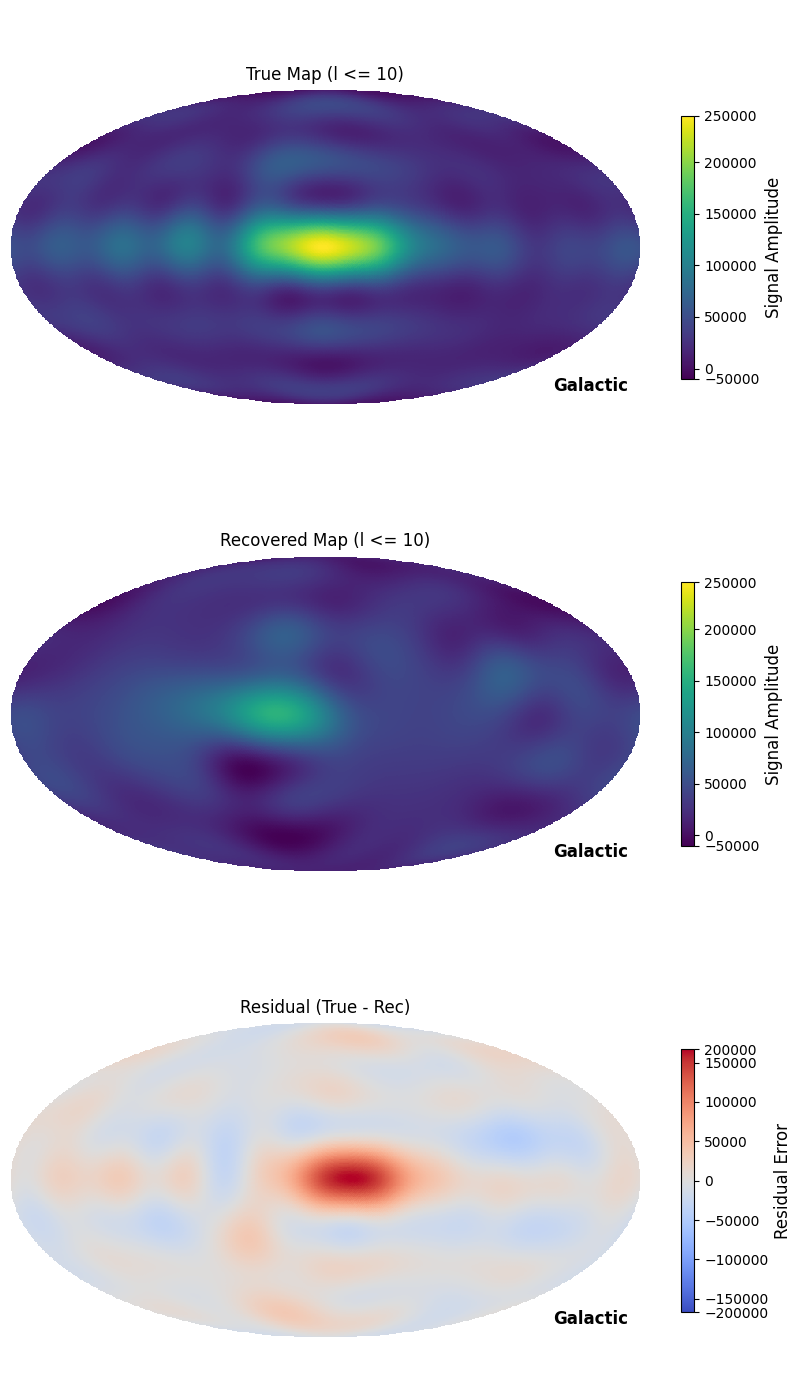

In [5]:
plot_maps_and_residuals(x_true, x_rec["mars-dip_nv-dip"], lmax, 10, nside=128, plot_galactic=True)

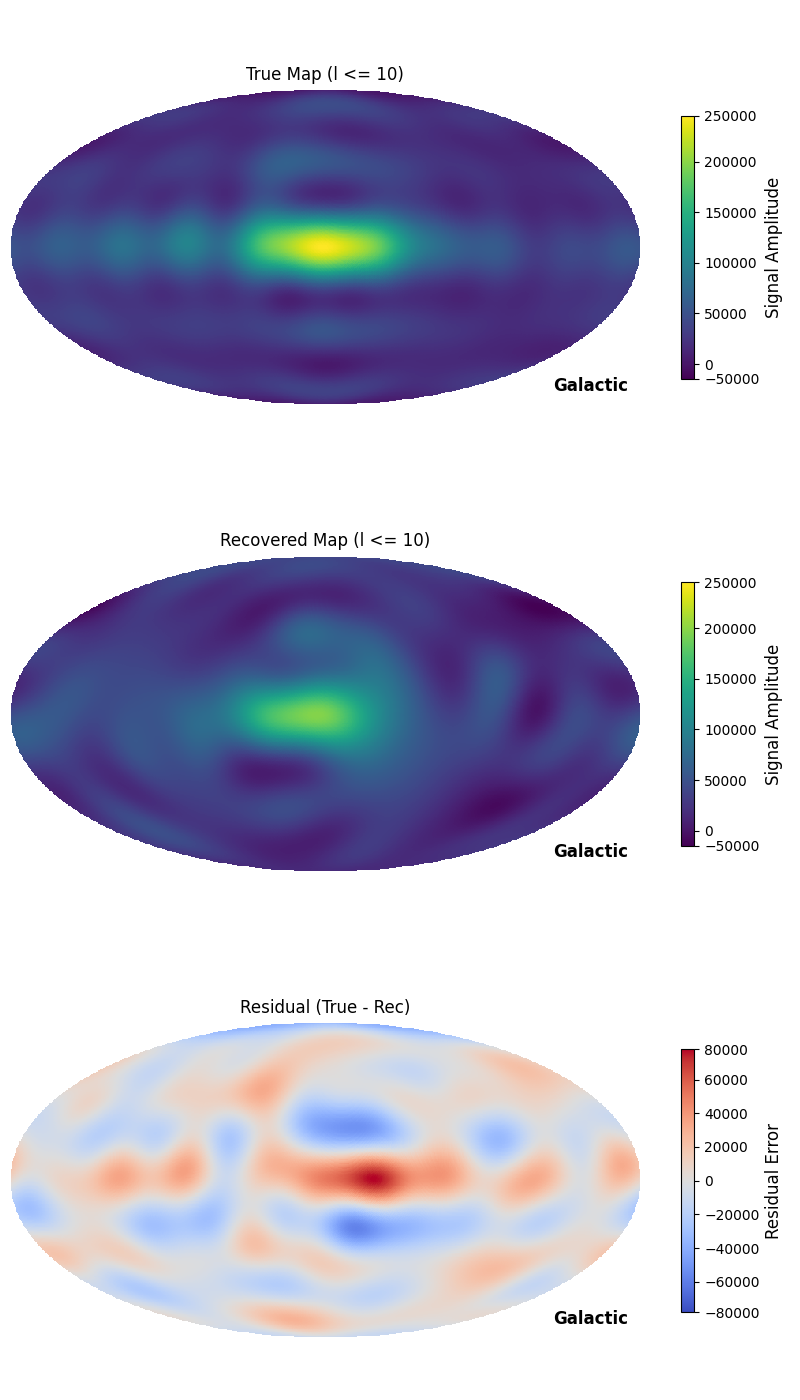

In [6]:
plot_maps_and_residuals(x_true, x_rec["mars-dip_nv-mono-dip"], lmax, 10, nside=128, plot_galactic=True)